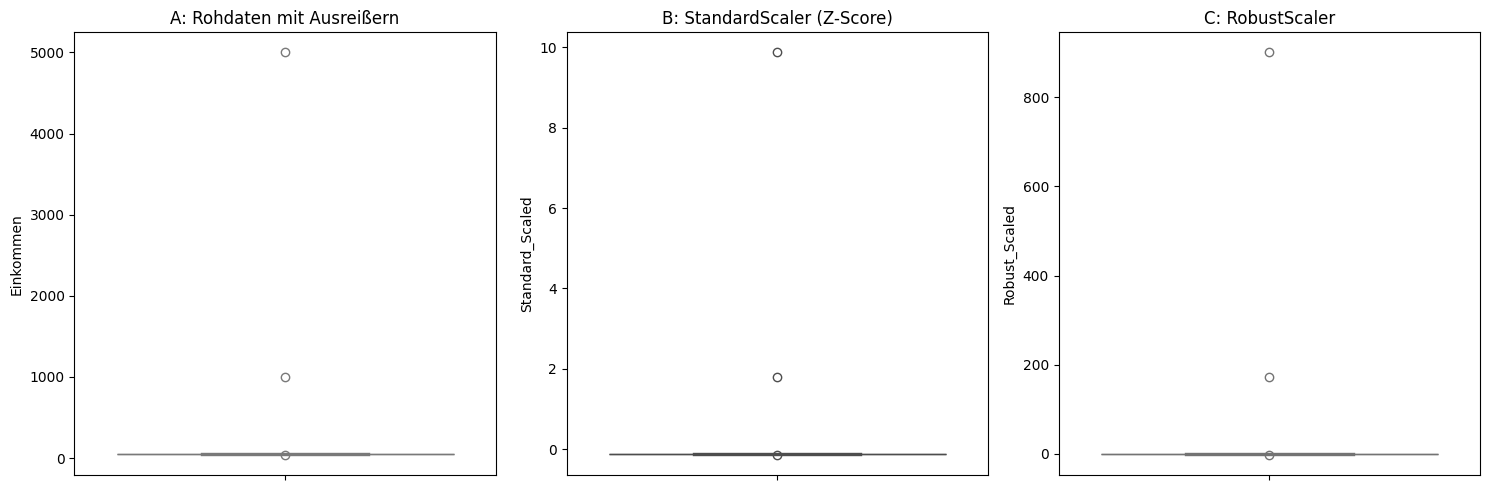

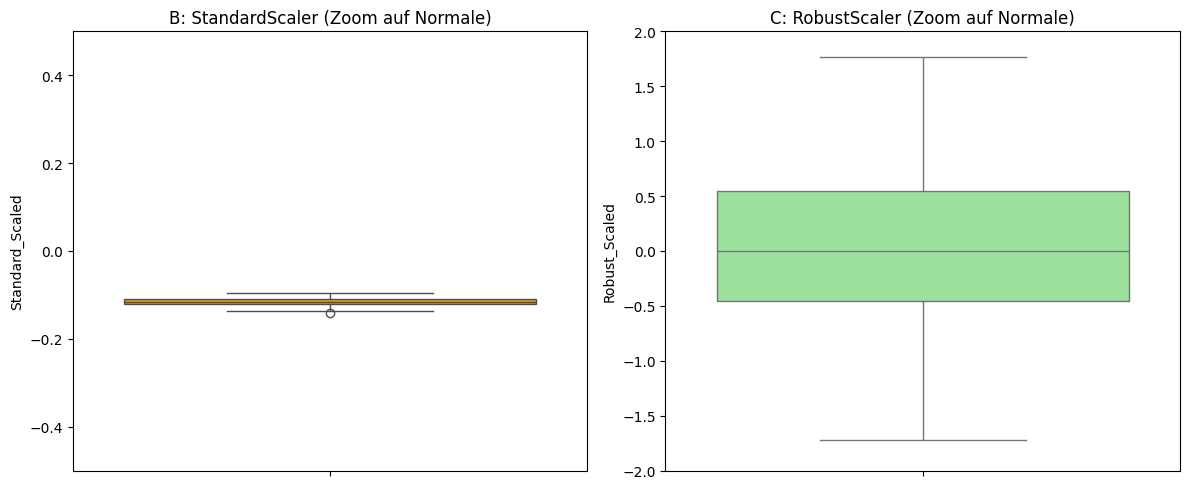

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler

# 1. Wir simulieren Daten: 100 "normale" Menschen und 2 Milliardäre
np.random.seed(42)
normale_daten = np.random.normal(loc=50, scale=5, size=100) # Mittelwert 50, Std 5
ausreisser = np.array([1000, 5000]) # Die "Bill Gates" Werte

# Zusammenfügen
daten = np.concatenate([normale_daten, ausreisser]).reshape(-1, 1)

# In einen DataFrame packen für schönere Plots
df = pd.DataFrame(daten, columns=['Einkommen'])

# 2. Skalierung anwenden
scaler_std = StandardScaler()
scaler_rob = RobustScaler()

df['Standard_Scaled'] = scaler_std.fit_transform(df[['Einkommen']])
df['Robust_Scaled'] = scaler_rob.fit_transform(df[['Einkommen']])

# 3. Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot A: Rohdaten (Man sieht fast nichts wegen der Skala)
sns.boxplot(y=df['Einkommen'], ax=axes[0], color='lightblue')
axes[0].set_title('A: Rohdaten mit Ausreißern')

# Plot B: StandardScaler (Die normalen Daten werden "zerquetscht")
sns.boxplot(y=df['Standard_Scaled'], ax=axes[1], color='orange')
axes[1].set_title('B: StandardScaler (Z-Score)')

# Plot C: RobustScaler (Die Struktur bleibt erhalten)
sns.boxplot(y=df['Robust_Scaled'], ax=axes[2], color='lightgreen')
axes[2].set_title('C: RobustScaler')

plt.tight_layout()
plt.show()

# Wir zoomen auf den Bereich, wo die normalen Daten liegen
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Zoom auf StandardScaler
sns.boxplot(y=df['Standard_Scaled'], ax=axes[0], color='orange')
axes[0].set_title('B: StandardScaler (Zoom auf Normale)')
axes[0].set_ylim(-0.5, 0.5)  # Wir schauen uns nur den Bereich um 0 an

# Zoom auf RobustScaler
sns.boxplot(y=df['Robust_Scaled'], ax=axes[1], color='lightgreen')
axes[1].set_title('C: RobustScaler (Zoom auf Normale)')
axes[1].set_ylim(-2, 2)      # Der normale Bereich beim RobustScaler

plt.tight_layout()
plt.show()

Wichtigkeit der Komponenten (Explained Variance Ratio):
PC1 (Hauptachse): 79.60%
PC2 (Nebenachse): 20.40%
------------------------------
Die Richtungsvektoren (Eigenvektoren):
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]


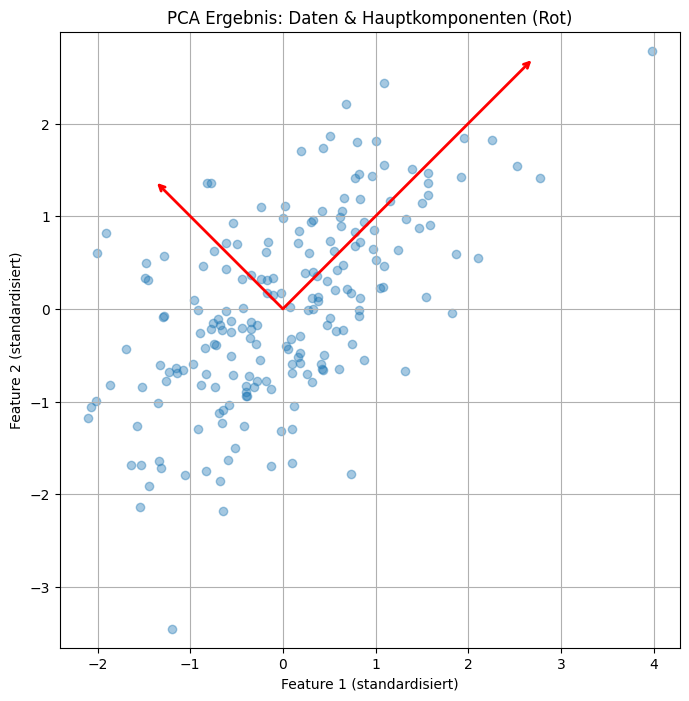

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# --- SCHRITT 1: Daten generieren (Unsere "Zigarre") ---
np.random.seed(42)
n_samples = 200

# Wir erzeugen eine Punktewolke, die schräg liegt (korreliert)
C = np.array([[0.1, 0.7], [3.5, 0.5]]) # Mischmatrix für die Form
X_raw = np.dot(np.random.randn(n_samples, 2), C) # Rohdaten

# --- SCHRITT 2: Skalierung (Das Wichtigste!) ---
# Wir nutzen StandardScaler, da unsere Daten keine extremen Ausreißer haben
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# --- SCHRITT 3: Die PCA durchführen ---
# Wir wollen alle Komponenten sehen (n_components=2)
pca = PCA(n_components=2)
pca.fit(X_scaled)

# --- SCHRITT 4: Ergebnisse auslesen ---
print("Wichtigkeit der Komponenten (Explained Variance Ratio):")
print(f"PC1 (Hauptachse): {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 (Nebenachse): {pca.explained_variance_ratio_[1]*100:.2f}%")
print("-" * 30)
print("Die Richtungsvektoren (Eigenvektoren):")
print(pca.components_)

# --- SCHRITT 5: Visualisierung ---
def draw_vector(v0, v1, ax=None):
    ax = ax or plt.gca()
    arrowprops=dict(arrowstyle='->', linewidth=2, shrinkA=0, shrinkB=0, color='red')
    ax.annotate('', v1, v0, arrowprops=arrowprops)

plt.figure(figsize=(8, 8))
# Die Daten plotten (wir nehmen die skalierten Daten)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], alpha=0.4, label='Datenpunkte')

# Die Vektoren einzeichnen
# pca.mean_ ist nach Standardisierung theoretisch [0,0], aber gut für die Form
origin = pca.mean_ 

for length, vector in zip(pca.explained_variance_, pca.components_):
    v = vector * 3 * np.sqrt(length) # Skalieren für bessere Sichtbarkeit
    draw_vector(origin, origin + v)

plt.title('PCA Ergebnis: Daten & Hauptkomponenten (Rot)')
plt.xlabel('Feature 1 (standardisiert)')
plt.ylabel('Feature 2 (standardisiert)')
plt.grid(True)
plt.axis('equal') # Wichtig, damit die Winkel stimmen!
plt.show()